# Detecção de Placas com YOLOv8m + OCR
<p align="left">
  <img src="https://miro.medium.com/v2/resize:fit:1358/1*bSLNlG7crv-p-m4LVYYk3Q.png" width="360" style="display:inline-block;"/>
  <img src="https://play-lh.googleusercontent.com/02-8ZoVumyq5XGnyqz4ftm9lAJ0RNHTr5wHpPqSZjDedePNC-UmhAQDGh_sMsucmrqY=w3840-h2160-rw" width="420" style="display:inline-block;"/>
</p>

- **Classificação:** Separa veículos de 4+ rodas vs Motos.
- **Leitura das placas:** Extrai o texto da placa usando `EasyOCR`.


# Instalando as bibliotecas

In [1]:
!pip install easyocr ultralytics matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.2 MB/s eta 0:00:00


# Baixando o dataset das placas e o dataset com nossas fotos e vídeos

In [ ]:
# dataset placas
!gdown 1Ftb3BFty7pelFWIFAzb-ajUZ_IU9Bgws

# nosso dataset
!gdown 1rto67QKBR5LtDebz20Q3UsnPoJnzsLNz

# Descompactação dos Datasets

In [3]:
!unzip -q "License Plate Recognition.v11i.yolo26.zip" -d dataset
!unzip -q "dataset_proprio-20260612T130719Z-3-001" -d dataset_proprio

# Imports

In [ ]:
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

import ultralytics
ultralytics.checks()

plt.rcParams['figure.dpi'] = 110
%matplotlib inline



# Configs pro treino do modelo

In [5]:
PASTA_DATASET = r'./dataset'
TEST_IMG_DIR  = os.path.join(PASTA_DATASET, 'test', 'images')
CAMINHO_YAML  = os.path.join(PASTA_DATASET, 'data.yaml')
max_workers = os.cpu_count()
SIZES = [128 , 640]
IMG_SIZE = SIZES[1]

# Configurações de Treino (Modelo Médio, Resolução 640)
TRAIN_CONFIG = dict(
    data          = CAMINHO_YAML,
    epochs        = 30,
    imgsz         = IMG_SIZE,
    batch         = -1,
    workers       = max_workers,
    device        = 0,
    patience      = 10,
    cache         = 'ram',
    amp           = True,
    rect          = True,
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    warmup_epochs = 2,
    cos_lr        = True,
    close_mosaic  = 10,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.05,
    project       = 'runs',
    name          = 'detect/placa_v8m_640',
    exist_ok      = True,
    verbose       = True,
    plots         = True,
    save          = True,
)

# YOLO V8M

In [ ]:
plate_model = YOLO('yolov8m.pt')

# Treinamento do Modelo

In [ ]:
results_treino = plate_model.train(**TRAIN_CONFIG)

# Nosso modelo já treinado

In [ ]:
!gdown 1u9tkLpADVtYExU6fYKtSgPwyUXtlvnjj

# Descompactação do modelo treinado

In [10]:
!unzip -q "runs.zip"

# Avaliação do desempenho do modelo


  AVALIAÇÃO DO MODELO
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 875.7±411.1 MB/s, size: 17.6 KB)
val: Scanning /content/dataset/valid/labels... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 2.3Kit/s 0.9s
val: New cache created: /content/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 3.2it/s 40.2s
                   all       2048       2195      0.982      0.901      0.956       0.65
Speed: 0.8ms preprocess, 14.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-2

  mAP50   : 0.956
  mAP50-95: 0.650
  Precisão: 0.982
  Recall  : 0.901


  GRÁFICOS DE TREINAMENTO

Exibindo: results.png


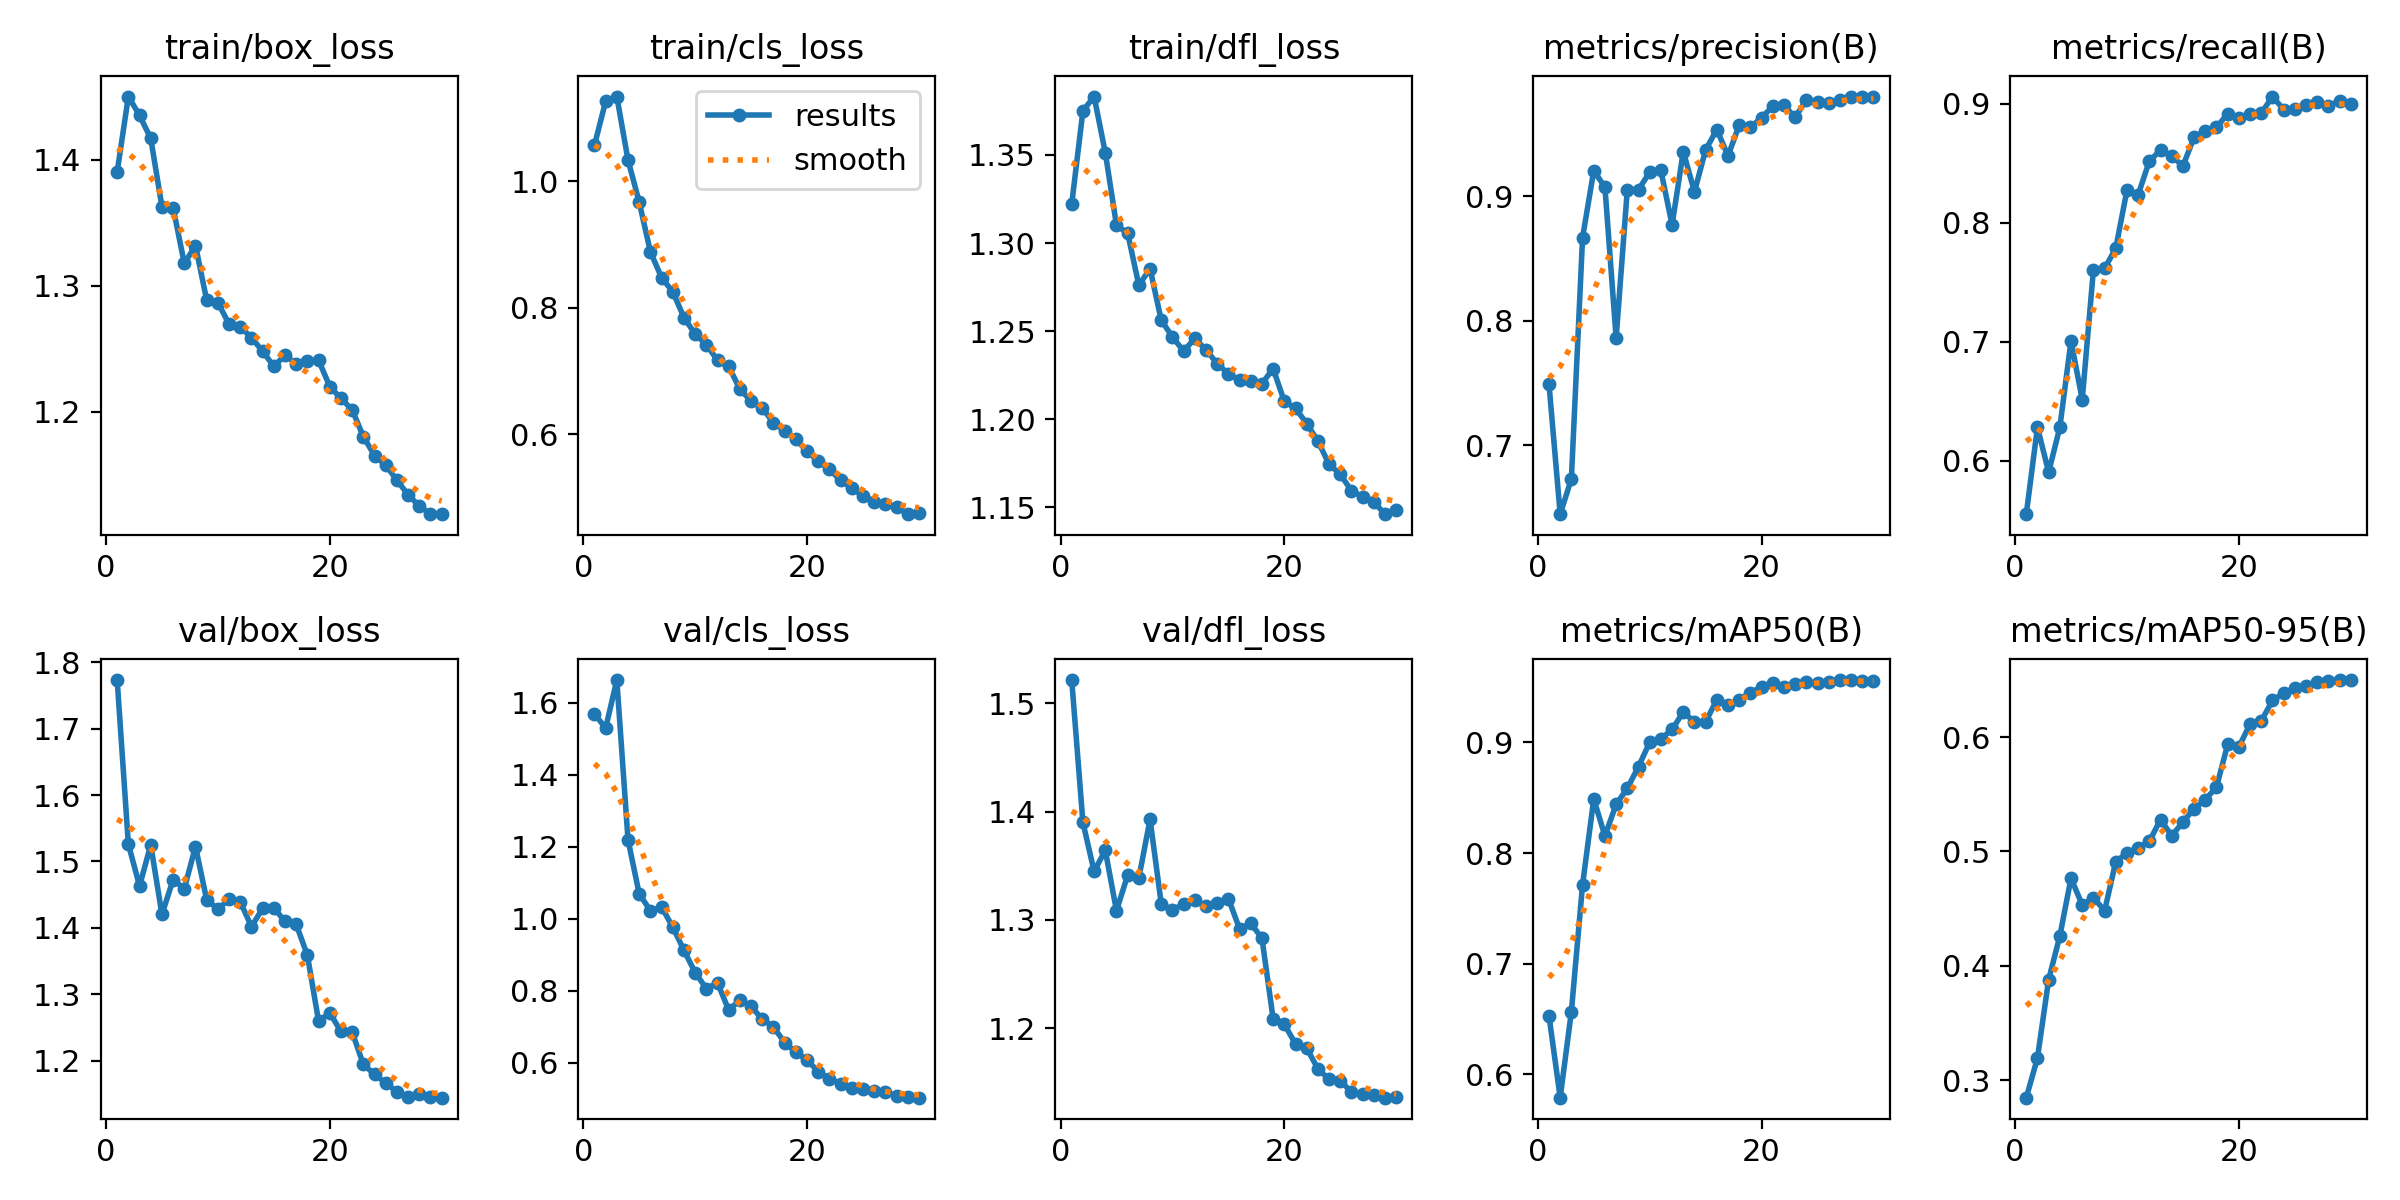


Exibindo: confusion_matrix.png


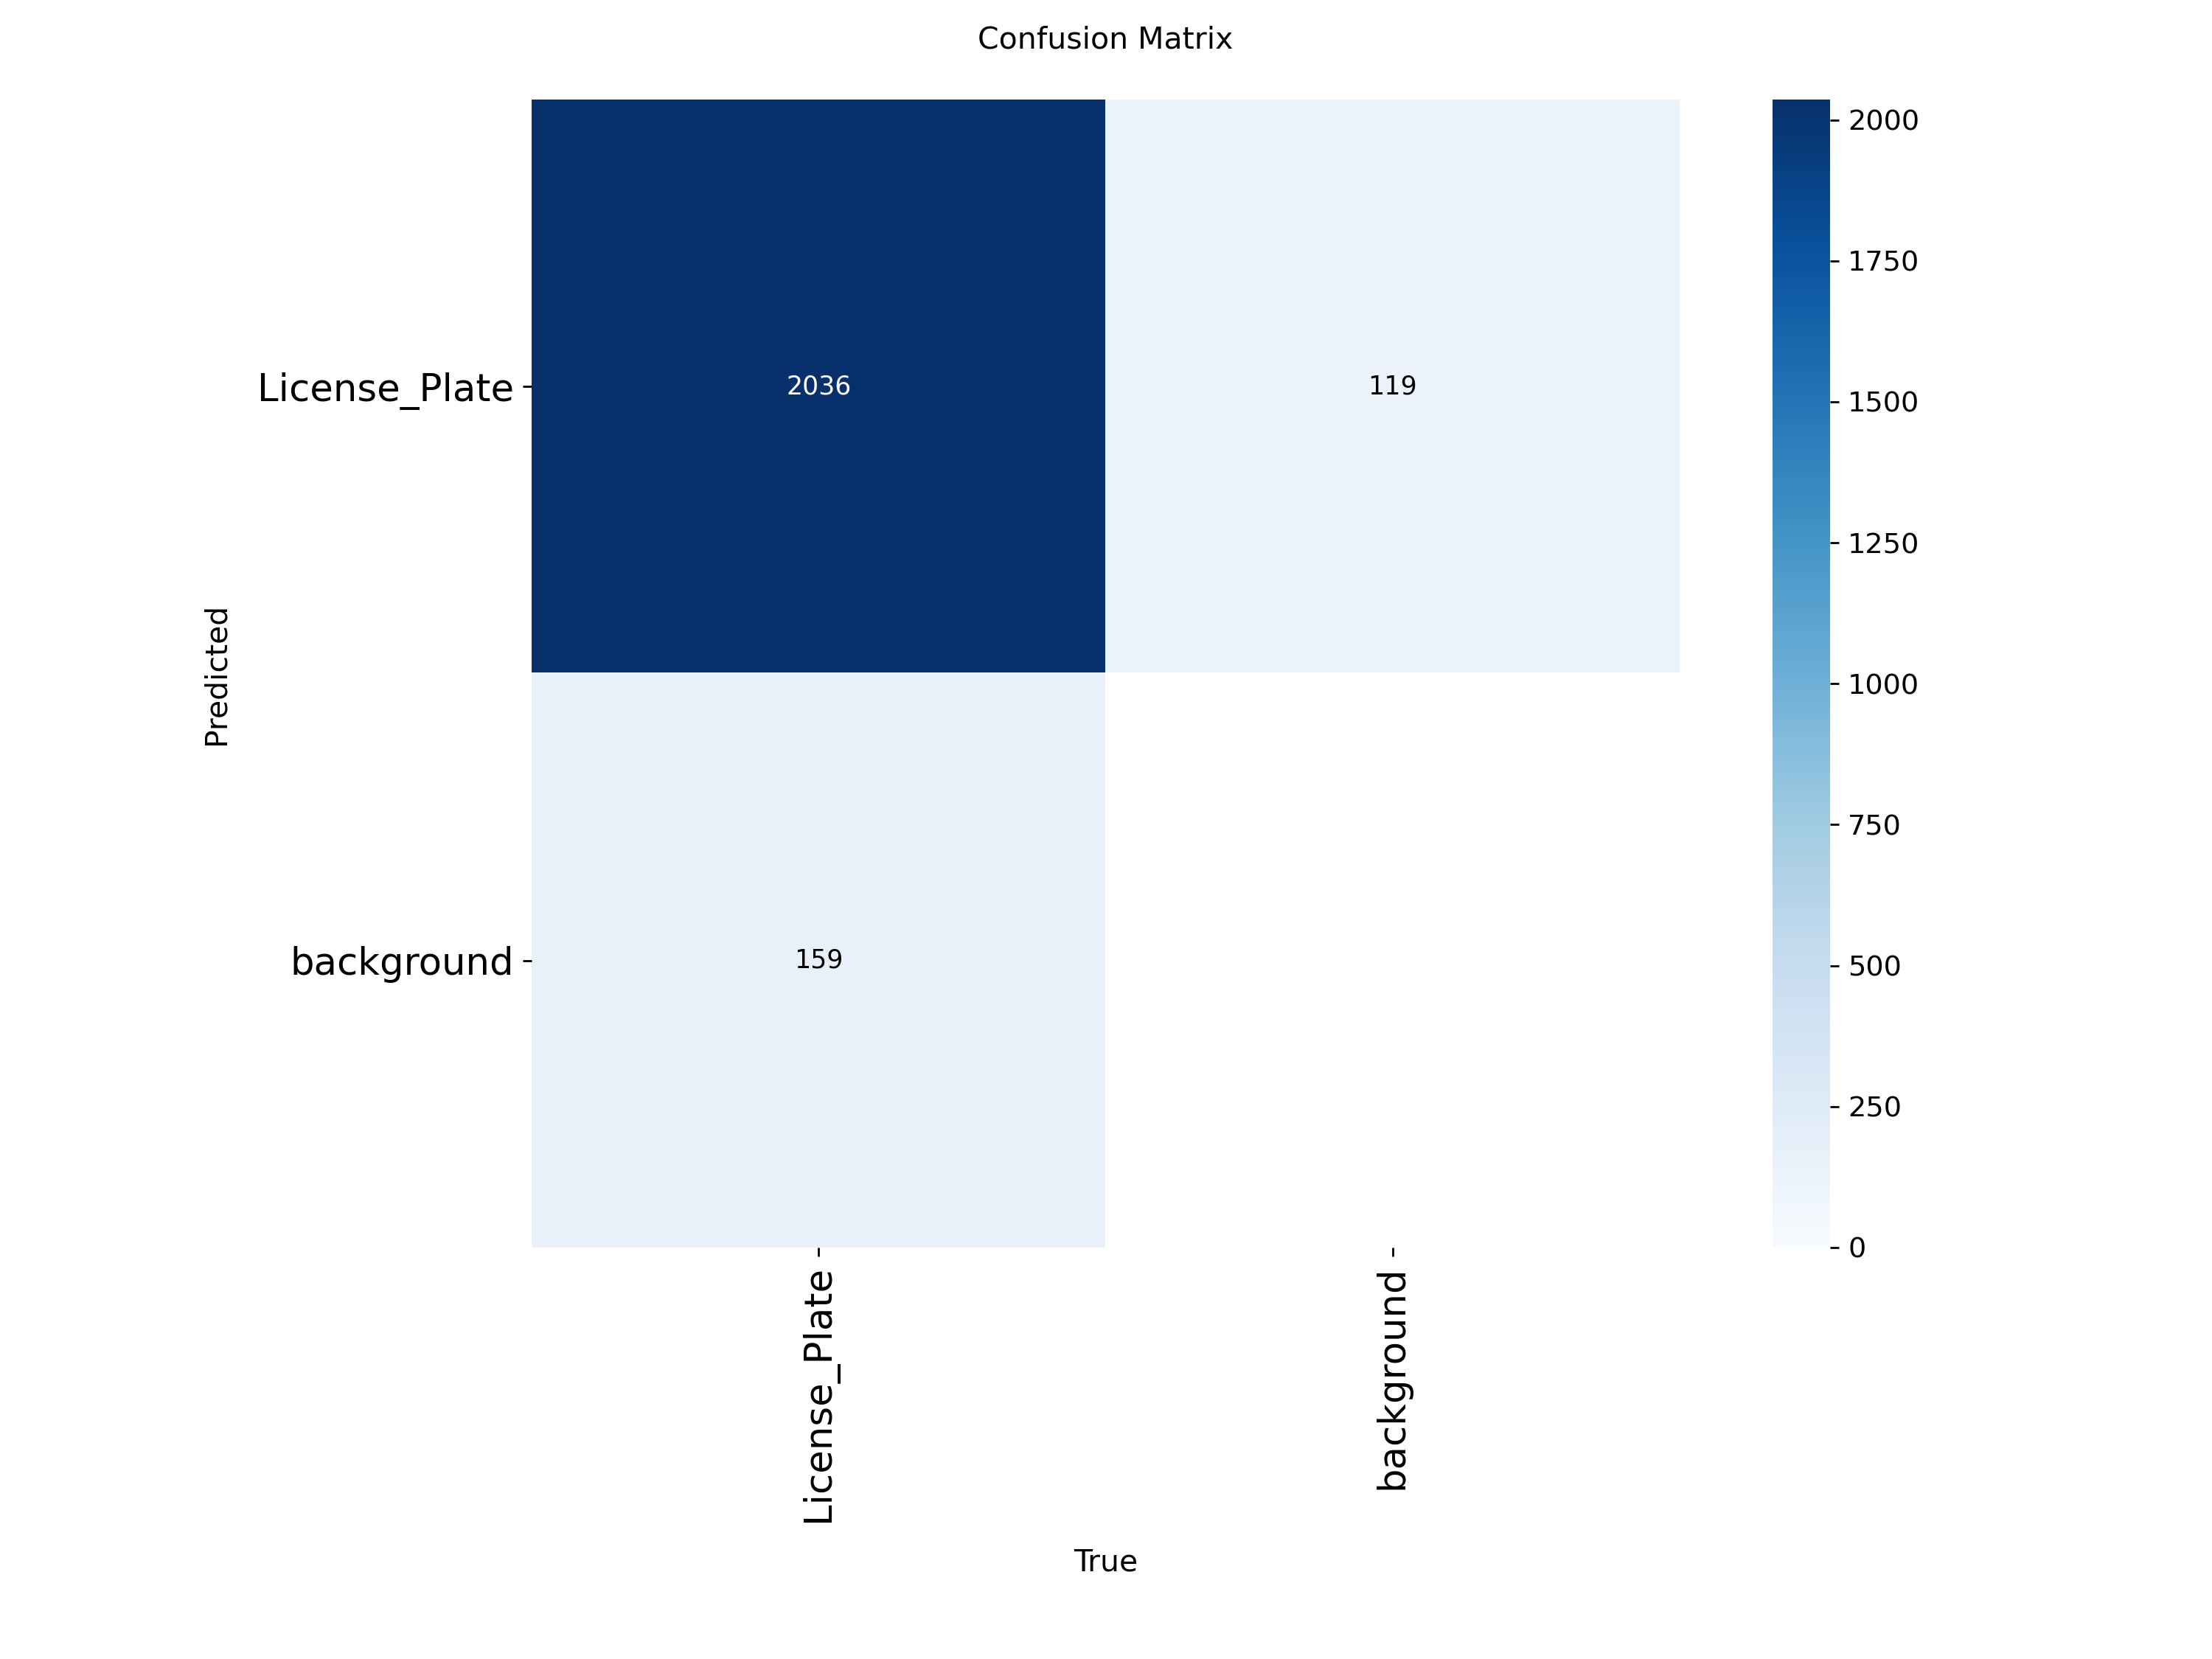

In [23]:
import os
import glob
import torch
from ultralytics import YOLO
from IPython.display import Image, display

print("\n============================================================")
print("  AVALIAÇÃO DO MODELO")
print("============================================================")

# Use results_treino.save_dir if available, otherwise fallback to glob.glob
if 'results_treino' in locals() and results_treino is not None and hasattr(results_treino, 'save_dir'):
    train_base_dir = results_treino.save_dir
    BEST_PT_PATH = os.path.join(train_base_dir, 'weights', 'best.pt')
else:
    # Fallback if results_treino is not available (e.g., notebook restarted without retraining)
    # Changed glob pattern to be exact, no '*'
    pastas = sorted(glob.glob('/content/runs/detect/runs/detect/placa_v8m_640'), key=os.path.getmtime)
    if pastas:
        train_base_dir = pastas[-1] # This is the full path to the run folder
        BEST_PT_PATH = os.path.join(train_base_dir, 'weights', 'best.pt')
    else:
        # Final fallback if nothing is found
        BEST_PT_PATH = 'yolov8m.pt' # Fallback
        train_base_dir = '' # Indicate no specific training folder found

# Carrega o modelo do seu HD
modelo_avaliador = YOLO(BEST_PT_PATH)
curr_device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Roda a validação
metrics = modelo_avaliador.val(data='./dataset/data.yaml', imgsz=640, device=curr_device)

# Imprime as métricas numéricas
print(f"\n  mAP50   : {metrics.box.map50:.3f}")
print(f"  mAP50-95: {metrics.box.map:.3f}")
print(f"  Precisão: {metrics.box.mp:.3f}")
print(f"  Recall  : {metrics.box.mr:.3f}\n")

print("\n============================================================")
print("  GRÁFICOS DE TREINAMENTO")
print("============================================================")

# train_folder should be train_base_dir if derived from results_treino or glob
if train_base_dir and os.path.exists(train_base_dir):
    graficos = ['results.png', 'confusion_matrix.png', 'PR_curve.png']
    for graf in graficos:
        caminho_graf = os.path.join(train_base_dir, graf)
        if os.path.exists(caminho_graf):
            print(f"\nExibindo: {graf}")
            display(Image(filename=caminho_graf))
else:
    print("Pasta do treinamento não encontrada.")

# Parte pra identificar os textos das placas e os plots dos veículos e boxes

In [6]:
import cv2
import torch
import easyocr
from ultralytics import YOLO

class AdvancedPlateDetector:
    COCO_VEHICLES = {2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck'}

    def __init__(self, plate_model_path, car_model_path='yolov8m.pt', device='auto'):
        if device == 'auto': device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device = device
        print(f'[AdvancedDetector] Rodando na: {device.upper()}')

        self.car_model = YOLO(car_model_path)
        self.plate_model = YOLO(plate_model_path) if isinstance(plate_model_path, str) else plate_model_path

        print('[AdvancedDetector] Carregando a Inteligência de Texto (EasyOCR)...')
        self.reader = easyocr.Reader(['en'], gpu=(device=='cuda'))
        print('Pronto!')

    def preprocess_for_ocr(self, crop):
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe.apply(gray)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return thresh

    def detect(self, image_bgr):
        h_orig, w_orig = image_bgr.shape[:2]
        out = {'vehicles': [], 'plates': []}

        v_preds = self.car_model.predict(image_bgr, imgsz=640, conf=0.35, classes=list(self.COCO_VEHICLES.keys()), verbose=False, device=self.device)
        for pred in v_preds:
            for box in pred.boxes:
                cls_id = int(box.cls[0])
                if cls_id not in self.COCO_VEHICLES: continue
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                out['vehicles'].append({'bbox': [x1, y1, x2, y2], 'class': self.COCO_VEHICLES[cls_id], 'conf': float(box.conf[0])})

        crops = []
        if not out['vehicles']:
            crops.append({'bbox': [0,0,w_orig,h_orig], 'v_type': 'Unknown'})
        else:
            for v in out['vehicles']:
                x1, y1, x2, y2 = v['bbox']
                px, py = int((x2-x1)*0.1), int((y2-y1)*0.1)
                cx1, cy1 = max(0, x1-px), max(0, y1-py)
                cx2, cy2 = min(w_orig, x2+px), min(h_orig, y2+py)
                crops.append({'bbox': [cx1, cy1, cx2, cy2], 'v_type': 'Motorcycle' if v['class'] == 'Motorcycle' else 'Car/Truck'})

        for crop_info in crops:
            cx1, cy1, cx2, cy2 = crop_info['bbox']
            crop_img = image_bgr[cy1:cy2, cx1:cx2]
            if crop_img.size == 0: continue

            p_preds = self.plate_model.predict(crop_img, imgsz=640, conf=0.25, verbose=False, device=self.device)
            for p in p_preds:
                for b in p.boxes:
                    px1, py1, px2, py2 = map(int, b.xyxy[0].tolist())
                    plate_crop = crop_img[max(0, py1):min(crop_img.shape[0], py2), max(0, px1):min(crop_img.shape[1], px2)]
                    text = ''
                    if plate_crop.size > 0:
                        ocr_img = self.preprocess_for_ocr(plate_crop)
                        res = self.reader.readtext(ocr_img, detail=0, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-')
                        text = ''.join(res)

                    out['plates'].append({
                        'bbox': [cx1+px1, cy1+py1, cx1+px2, cy1+py2],
                        'conf': float(b.conf[0]),
                        'v_type': crop_info['v_type'],
                        'text': text
                    })
        return out

    def draw(self, image_bgr, results):
        out = image_bgr.copy()
        tk = max(2, int(out.shape[1]*0.003))
        fs = max(0.45, out.shape[1]/900)

        for v in results['vehicles']:
            x1, y1, x2, y2 = v['bbox']
            color = (0, 165, 255) if v['class'] == 'Motorcycle' else (0, 200, 50)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, tk)
            cv2.putText(out, f"{v['class']} {v['conf']:.0%}", (x1, max(20, y1-10)), cv2.FONT_HERSHEY_SIMPLEX, fs, color, tk)

        for p in results['plates']:
            x1, y1, x2, y2 = p['bbox']
            color = (255, 60, 0)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, tk)

            # Aqui imprimimos apenas LICENSE_PLATE embaixo da caixa (y2) pra não misturar
            label = f"LICENSE_PLATE {p['conf']:.0%}"
            cv2.putText(out, label, (x1, min(out.shape[0]-5, y2 + 20)), cv2.FONT_HERSHEY_SIMPLEX, fs, (255,255,255), tk+1)
            cv2.putText(out, label, (x1, min(out.shape[0]-5, y2 + 20)), cv2.FONT_HERSHEY_SIMPLEX, fs, (0,0,0), 1)

        return out

# Utilização

In [ ]:
import glob
import os

# Se a variável BEST_PT_PATH se perdeu, a gente rastreia o arquivo no HD
if 'BEST_PT_PATH' not in locals() or BEST_PT_PATH is None:
    # Search for 'best.pt' recursively within the '/content' directory
    # This is a broader search to account for varied unzipping structures.
    all_best_pts = glob.glob('/content/**/weights/best.pt', recursive=True)
    if all_best_pts:
        # Assuming the most recently modified 'best.pt' is the one we want
        BEST_PT_PATH = max(all_best_pts, key=os.path.getmtime)
    else:
        BEST_PT_PATH = 'yolov8m.pt' # Fallback if no best.pt is found

print(f"[AdvancedDetector] Usando o modelo em: {BEST_PT_PATH}")

# Liga a classe do Detector passando o caminho encontrado
detector = AdvancedPlateDetector(plate_model_path=BEST_PT_PATH)

# Teste com 4 imagens aleatórias do nosso dataset de fotos

================ RESULTADOS DO OCR ================

Foto: saddsaasddas.jpeg | Tipo: [Car/Truck] | PLACA LIDA: THQ2J86 | Confiança: 0.74
Foto: saddsaasddas.jpeg | Tipo: [Car/Truck] | PLACA LIDA: Z3 | Confiança: 0.73
Foto: saddsaasddas.jpeg | Tipo: [Car/Truck] | PLACA LIDA: THO2J80 | Confiança: 0.74
Foto: saddsaasddas.jpeg | Tipo: [Car/Truck] | PLACA LIDA: TZOC69 | Confiança: 0.68
Foto: carro.jpeg | Tipo: [Car/Truck] | PLACA LIDA: GE-EUSC4DPNQ2543 | Confiança: 0.66
Foto: carro.jpeg | Tipo: [Car/Truck] | PLACA LIDA: L | Confiança: 0.29
Foto: carro.jpeg | Tipo: [Car/Truck] | PLACA LIDA: IVV | Confiança: 0.70
Foto: carro.jpeg | Tipo: [Car/Truck] | PLACA LIDA: N | Confiança: 0.68
Foto: WhatsApp Image 2026-06-10 at 16.29.45.jpeg | Tipo: [Car/Truck] | PLACA LIDA: PNO2543CE-EUSIID | Confiança: 0.79
Foto: WhatsApp Image 2026-06-10 at 16.29.45.jpeg | Tipo: [Car/Truck] | PLACA LIDA: SHII | Confiança: 0.77
Foto: WhatsApp Image 2026-06-10 at 16.29.45.jpeg | Tipo: [Car/Truck] | PLACA LIDA: SBHM | Co

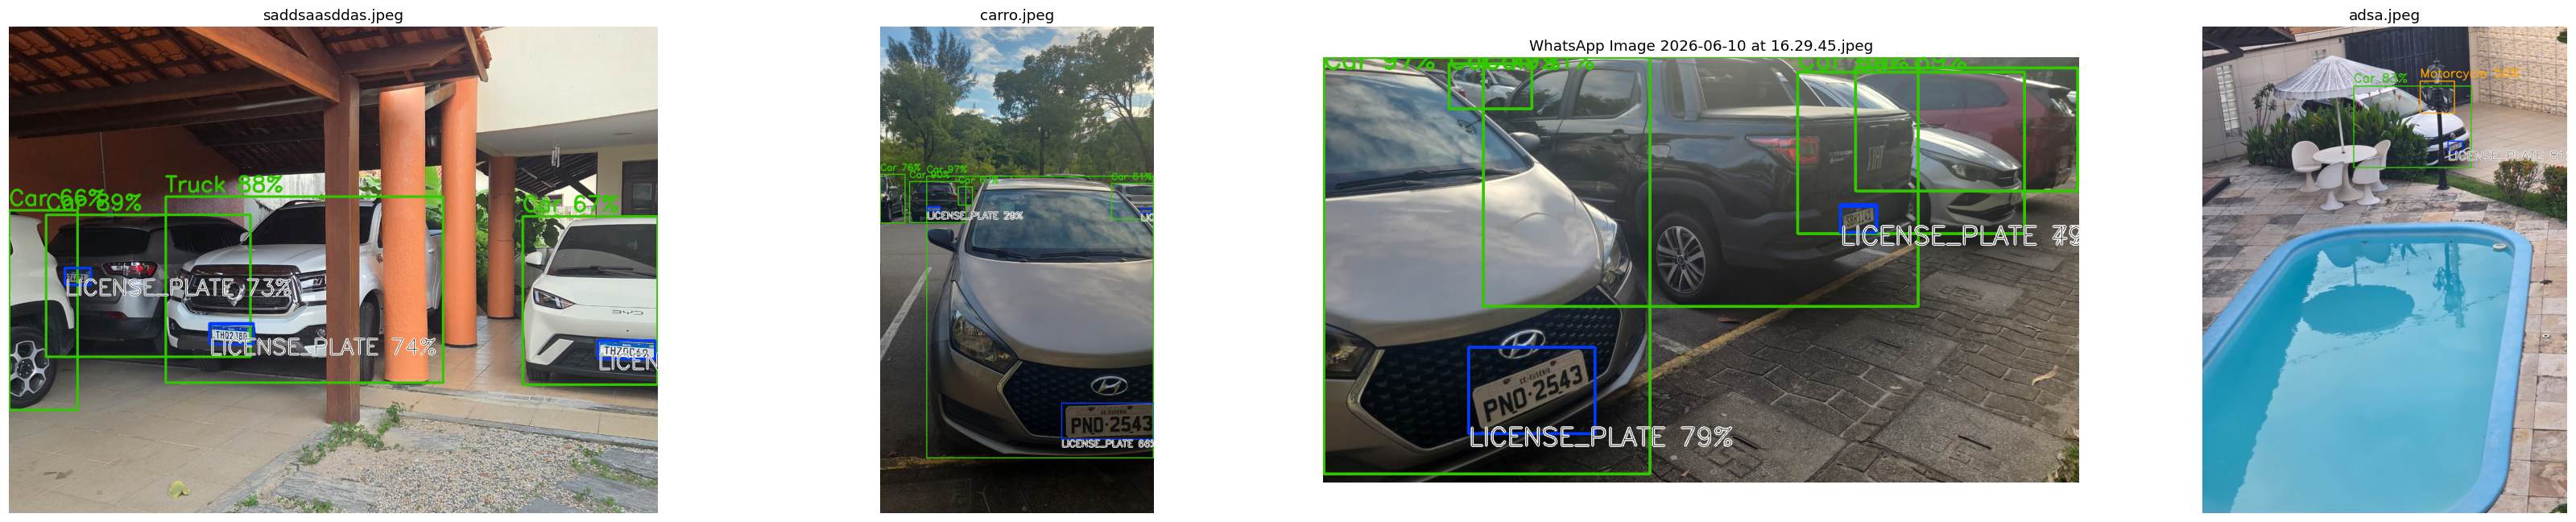

In [26]:
%matplotlib inline
import random
import os
import cv2
import matplotlib.pyplot as plt

# Apontando para as SUAS imagens
MINHAS_FOTOS = r'/content/dataset_proprio/dataset_proprio/fotos'

image_files = [f for f in os.listdir(MINHAS_FOTOS) if f.endswith(('.jpg','.jpeg','.png'))]
samples = random.sample(image_files, min(4, len(image_files)))

fig, axes = plt.subplots(1, len(samples), figsize=(8*len(samples), 6))
if len(samples) == 1: axes = [axes]

print("================ RESULTADOS DO OCR ================\n")

for ax, fname in zip(axes, samples):
    img = cv2.imread(os.path.join(MINHAS_FOTOS, fname))

    res = detector.detect(img)
    ann = detector.draw(img, res)

    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(fname)

    # Imprime no terminal em formato de texto limpo
    placas_encontradas = res['plates']
    if placas_encontradas:
        for p in placas_encontradas:
            print(f"Foto: {fname} | Tipo: [{p['v_type']}] | PLACA LIDA: {p['text']} | Confiança: {p['conf']:.2f}")
    else:
        print(f"Foto: {fname} | Nenhuma placa detectada.")

print("\n===================================================")

plt.tight_layout()
plt.show()

# Teste com um vídeo aleatório do nosso dataset

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os
import random
import cv2

MINHAS_VIDEOS = r'/content/dataset_proprio/dataset_proprio/videos'

# Encontrar arquivos de vídeo
video_files = [f for f in os.listdir(MINHAS_VIDEOS) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

if not video_files:
    print(f"Nenhum vídeo encontrado em '{MINHAS_VIDEOS}'. Por favor, verifique o caminho e o conteúdo da pasta.")
else:
    # Selecionar um vídeo aleatório
    random_video_fname = random.choice(video_files)
    input_video_path = os.path.join(MINHAS_VIDEOS, random_video_fname)
    output_video_path = f'/content/output_{random_video_fname}'

    print(f"Processando o vídeo: {random_video_fname}")

    cap = cv2.VideoCapture(input_video_path)

    # Obter propriedades do vídeo de entrada
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec para MP4
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Criar objeto VideoWriter
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count % 30 == 0: # Processa a cada 30 frames para acelerar (aprox. 1 frame por segundo)
            print(f"Processando frame {frame_count}...")

        res = detector.detect(frame)
        annotated_frame = detector.draw(frame, res)

        # Escrever o frame anotado no vídeo de saída
        out.write(annotated_frame)

        # Imprimir resultados do OCR para o frame atual
        placas_encontradas = res['plates']
        if placas_encontradas:
            for p in placas_encontradas:
                print(f"  Frame {frame_count} | Tipo: [{p['v_type']}] | PLACA LIDA: {p['text']} | Confiança: {p['conf']:.2f}")

    cap.release()
    out.release()

    print(f"Vídeo processado salvo em: {output_video_path}")

    # Exibir o vídeo processado no Colab
    try:
        # Para vídeos grandes, usar a tag <video> diretamente pode ser mais eficiente
        with open(output_video_path, 'rb') as f:
            video_data = f.read()
            data_url = "data:video/mp4;base64," + b64encode(video_data).decode()
            display(HTML(f"""<video width='800' controls><source src='{data_url}' type='video/mp4'></video>"""))
    except Exception as e:
        print(f"Erro ao exibir o vídeo: {e}")
        print("Você pode baixá-lo e assisti-lo localmente.")

# Obs: baixe o vídeo para assistir 😂😅
Não posso fazer nada, infelizmente, o colab quebrou minhas pernas